# Used Car Price Prediction — with MLflow Experiment Tracking

This is the original Kaggle notebook, adapted to **run locally** and to practice **MLflow Experiment Tracking**.

| | |
|---|---|
| **MLflow experiment name** | `used-car-price-prediction` |
| **Tracking store** | `./mlruns` (local file store, no server needed) |
| **Candidate models (one MLflow run each)** | LinearRegression, Ridge, RandomForest, SVR, XGBoost |
| **Primary metric for picking the best model** | **lowest test RMSE** (in dollars) |
| **Best model saved to** | `artifacts/models/best_model.pkl` (+ `model_metadata.json`) |
| **Retrain check** | If `artifacts/models/best_model.pkl` exists, training is **skipped** and the saved model is loaded instead |

**Expected project layout**

```text
project/
├── used-car-price-prediction.ipynb   <- this notebook
├── data/used_cars.csv                <- put the Kaggle CSV here
├── src/car_transformers.py           <- written by this notebook (needed to unpickle the model)
├── artifacts/models/                 <- best_model.pkl, model_metadata.json
├── artifacts/reports/                <- comparison.csv
└── mlruns/                           <- MLflow tracking data
```

**Requirements:** `pip install mlflow scikit-learn xgboost pandas numpy matplotlib seaborn joblib`

**Dataset:** [Used Car Price Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset) → save `used_cars.csv` into `data/`.

# Section 1 — Imports & Configuration

In [1]:
import os, sys, json, time, platform, warnings
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Hint: Inferred schema")     # harmless MLflow schema hint (int columns)

import logging
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)            # silence the pickle-format notice

In [2]:
# ---------------- Reproducibility & experiment settings ----------------
RANDOM_STATE = 42          # used for the split, the CV folds and every model that supports a seed
TEST_SIZE    = 0.2
CV_FOLDS     = 7           # same as the original notebook
PRIMARY_METRIC = "test_rmse"   # best model = LOWEST value of this metric

# ---------------- Behaviour switches ----------------
FORCE_RETRAIN = False      # True -> retrain even if artifacts/models/best_model.pkl already exists
QUICK_RUN     = False      # True -> tiny grids + 3-fold CV (just to see MLflow work in ~1 minute)

np.random.seed(RANDOM_STATE)

# ---------------- Local project paths (no Kaggle paths) ----------------
PROJECT_DIR   = Path.cwd()
DATA_PATH     = PROJECT_DIR / "data" / "used_cars.csv"
SRC_DIR       = PROJECT_DIR / "src"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
MODELS_DIR    = ARTIFACTS_DIR / "models"
REPORTS_DIR   = ARTIFACTS_DIR / "reports"

MODEL_PATH      = MODELS_DIR / "best_model.pkl"          # <- the saved best model (full pipeline)
METADATA_PATH   = MODELS_DIR / "model_metadata.json"
COMPARISON_PATH = REPORTS_DIR / "comparison.csv"

for d in (DATA_PATH.parent, SRC_DIR, MODELS_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project dir :", PROJECT_DIR)
print("Data file   :", DATA_PATH)
print("Model path  :", MODEL_PATH)

Project dir : d:\MLOPS-2
Data file   : d:\MLOPS-2\data\used_cars.csv
Model path  : d:\MLOPS-2\artifacts\models\best_model.pkl


### A small reusable transformer (`src/car_transformers.py`)

The original notebook target-encodes `brand` using the **training** data only. To make that step part of the saved
model (so `model.predict(raw_features)` works later without this notebook), it is turned into a scikit-learn transformer.
It lives in a real `.py` file — not in the notebook — so the pickled model can be loaded from FastAPI / Docker / another script later.
The logic is identical to the original: *brand → mean of log-price in the training set; unseen brands → overall training mean*.

In [3]:
%%writefile src/car_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class BrandTargetEncoder(BaseEstimator, TransformerMixin):
    """Replace `brand` by the mean target value of that brand (fit on training data only).

    Output keeps all other columns and appends `brand_encoded` as the last column
    (same layout as the original notebook).
    """

    def __init__(self, column="brand", output_column="brand_encoded"):
        self.column = column
        self.output_column = output_column

    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(np.asarray(y, dtype=float))
        self.mapping_ = y.groupby(X[self.column].to_numpy()).mean()
        self.global_mean_ = float(y.mean())
        self.columns_out_ = [c for c in X.columns if c != self.column] + [self.output_column]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X[self.output_column] = X[self.column].map(self.mapping_).fillna(self.global_mean_)
        return X[self.columns_out_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_out_, dtype=object)

Overwriting src/car_transformers.py


In [4]:
# Make `src/` importable (also for joblib worker processes used by GridSearchCV)
sys.path.insert(0, str(SRC_DIR))
os.environ["PYTHONPATH"] = str(SRC_DIR) + os.pathsep + os.environ.get("PYTHONPATH", "")

from car_transformers import BrandTargetEncoder

# Section 2 — MLflow Configuration

* **Tracking URI** `file:./mlruns` → everything is stored in a local folder; no server required.
* **Experiment** `used-car-price-prediction` → all runs of this project are grouped here, so they can be compared in the UI.

In [5]:
import inspect

# Recent MLflow versions (3.x) treat the local `./mlruns` file store as "maintenance mode" and refuse it
# unless this opt-in variable is set. It is harmless on older versions.
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

EXPERIMENT_NAME = "used-car-price-prediction"
TRACKING_URI    = "file:./mlruns"

mlflow.set_tracking_uri(TRACKING_URI)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

# MLflow >= 3 calls the argument `name`, MLflow 2.x calls it `artifact_path`. Support both.
_params = inspect.signature(mlflow.sklearn.log_model).parameters
MODEL_ARG = "name" if "name" in _params else "artifact_path"

print("MLflow version  :", mlflow.__version__)
print("Tracking URI    :", mlflow.get_tracking_uri())
print("Experiment      :", experiment.name, f"(id={experiment.experiment_id})")

MLflow version  : 3.16.1
Tracking URI    : file:./mlruns
Experiment      : used-car-price-prediction (id=616969341991758638)


# Section 3 — Dataset Loading

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}.\n"
        "Download 'used_cars.csv' from "
        "https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset "
        "and place it in the 'data/' folder."
    )

df = pd.read_csv(DATA_PATH)
n_rows_raw = len(df)
print("Raw dataset shape:", df.shape)

Raw dataset shape: (4009, 12)


# Section 4 — Data Exploration (EDA)

In [10]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [12]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [13]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

# Section 5 — Data Preprocessing

*(unchanged from the original notebook, except where noted)*

## Replace prefix

In [7]:
df['milage'] = df['milage'].str.replace(' mi.', '').str.replace(',', '').astype(int)

In [8]:
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(int)

## Feature Extraction

In [9]:
# Create hp column
df['hp'] = df['engine'].str.extract(r'(\d+\.\d+)HP').astype(float, errors='ignore')

# Create engine displacement
df['engine displacement'] = df['engine'].str.extract(r'(\d+\.\d+)\s*L')
df['engine displacement'] = df['engine displacement'].fillna(df['engine'].str.extract(r'(\d+\.\d+)\s*LITER')[0])
df['engine displacement'] = df['engine displacement'].astype(float, errors='ignore')

# Is it V type or not
df['is_v_engine'] = df['engine'].str.contains(r'V\d+', case=False, na=False)

## Cleaning the `fuel_type` feature

In [10]:
df['fuel_type'] = df['fuel_type'].str.strip().str.upper().replace({'PLUG-IN HYBRID': 'HYBRID', 'NOT SUPPORTED':'OTHER', '–':'OTHER'})

df['fuel_type'].value_counts()

fuel_type
GASOLINE         3309
HYBRID            228
E85 FLEX FUEL     139
DIESEL            116
OTHER              47
Name: count, dtype: int64

## Cleaning the `transmission` feature

In [11]:
def classify_transmission(transmission):
    T = str(transmission).upper()
    
    if 'M/T' in T or 'MT' in T or 'MANUAL' in T:
        return 'M/T'
    elif 'A/T' in T or 'AT' in T or 'AUTOMATIC' in T:
        return 'A/T'
    elif 'CVT' in T or 'VARIABLE' in T or 'SINGLE-SPEED' in T:
        return 'CVT'
    else:
        return 'OTHER'
    
df['transmission'] = df['transmission'].apply(classify_transmission)

df['transmission'].unique()

array(['A/T', 'OTHER', 'M/T', 'CVT'], dtype=object)

## Handle Missing Values

In [12]:
df['hp'] = df.groupby('brand')['hp'].transform(lambda x: x.fillna(x.mean()))

df.dropna(subset=['hp'], inplace=True)

In [13]:
most_common_fuel = df.groupby('brand')['fuel_type'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

df['fuel_type'] = df.apply(
    lambda row: most_common_fuel[row['brand']] if pd.isna(row['fuel_type']) else row['fuel_type'],
    axis=1
)

df['fuel_type'] = df['fuel_type'].fillna('OTHER')

In [14]:
most_common_displacement = df.groupby('brand')['engine displacement'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

df['engine displacement'] = df.apply(
    lambda row: most_common_displacement[row['brand']] if pd.isna(row['engine displacement']) else row['engine displacement'],
    axis=1
)

df['engine displacement'] = df['engine displacement'].fillna(df['engine displacement'].median())

## Remove Outliers

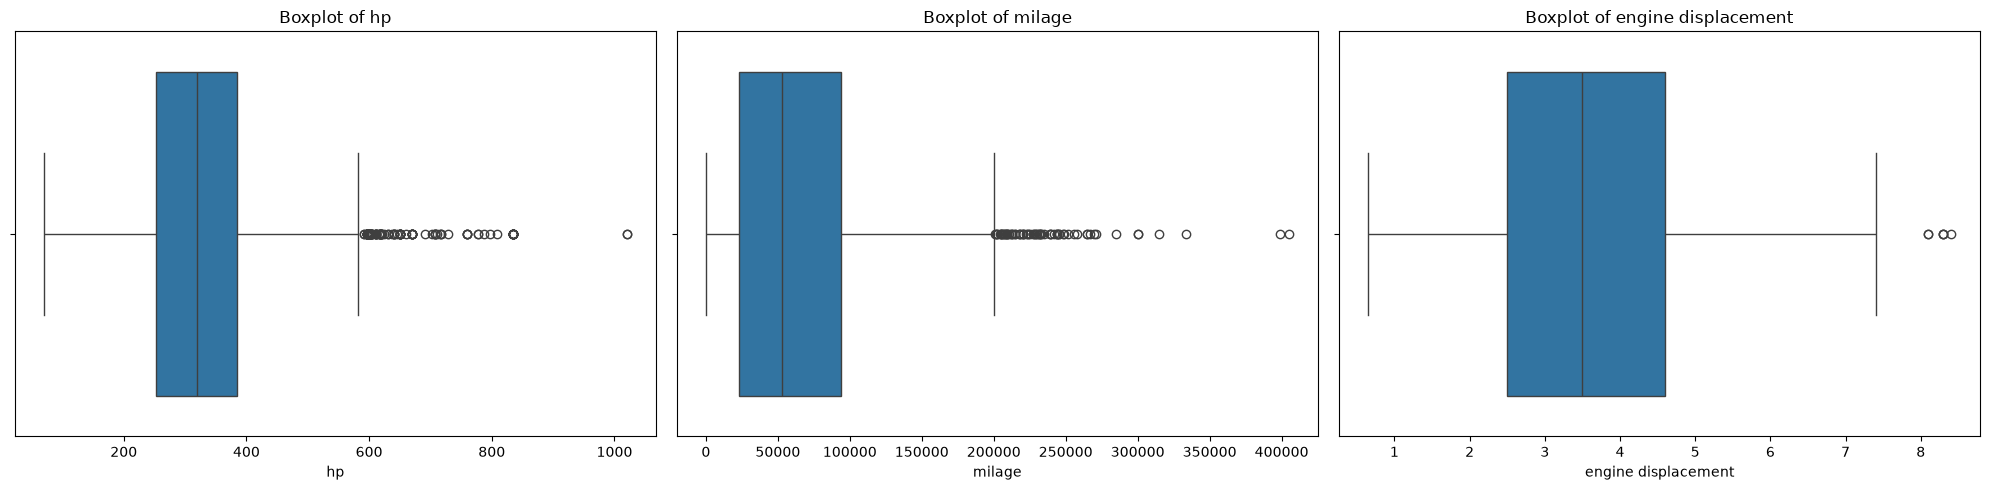

In [15]:
columns = ['hp', 'milage', 'engine displacement']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(f'{col}')

plt.tight_layout()
plt.show()
    

In [17]:
columns = ['engine displacement', 'hp', 'price', 'milage']
for col in columns:
    Q1 = df[col].quantile(0.25)  
    Q3 = df[col].quantile(0.75)   
    IQR = Q3 - Q1                    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [26]:
df.shape

(3606, 15)

## Encoding Categorical Features

In [18]:
df['Accident_Impact'] = df['accident'].apply(lambda x: 1 if x == 'At least 1 accident or damage reported' else 0)

In [19]:
df['clean_title'] = df['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)

In [20]:
vis_df = df.copy()
vis_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,hp,engine displacement,is_v_engine,Accident_Impact
0,Ford,Utility Police Interceptor Base,2013,51000,E85 FLEX FUEL,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,A/T,Black,Black,At least 1 accident or damage reported,1,10300,300.000000,3.7,True,1
1,Hyundai,Palisade SEL,2021,34742,GASOLINE,3.8L V6 24V GDI DOHC,A/T,Moonlight Cloud,Gray,At least 1 accident or damage reported,1,38005,246.700000,3.8,True,1
2,Lexus,RX 350 RX 350,2022,22372,GASOLINE,3.5 Liter DOHC,A/T,Blue,Black,None reported,0,54598,303.659259,3.5,False,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,HYBRID,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,A/T,Black,Black,None reported,1,15500,354.000000,3.5,True,0
4,Audi,Q3 45 S line Premium Plus,2021,9835,GASOLINE,2.0L I4 16V GDI DOHC Turbo,A/T,Glacier White Metallic,Black,None reported,0,34999,318.831250,2.0,False,0


The `LabelEncoder` code is the same as the original; the only addition is that the fitted label → integer mappings are remembered in
`label_encoder_classes` so they can be stored in the model metadata (needed later to build the same features at serving time).

In [21]:
categorical_columns = ['fuel_type', 'transmission', 'is_v_engine']
label_encoder_classes = {}   # NEW: remembered for model_metadata.json

for cat_col in categorical_columns:
    encoder = LabelEncoder()
    df[cat_col] = encoder.fit_transform(df[cat_col])
    label_encoder_classes[cat_col] = [str(c) for c in encoder.classes_]   # index in list == encoded integer

## Feature Engineering

In [22]:
df['Vehicle_Age'] = 2025 - df['model_year']

In [23]:
df['Mileage_per_Year'] = df.apply(
    lambda row: row['milage'] / row['Vehicle_Age'] if row['Vehicle_Age'] > 0 else row['milage'],
    axis=1
)

Binning is unchanged; `retbins=True` additionally keeps the quartile edges (stored in the metadata for later serving).

In [24]:
# Binning  (retbins=True only *keeps* the bin edges, the binning itself is unchanged)
df['Vehicle_Age_Bin'], age_bin_edges = pd.qcut(df['Vehicle_Age'], q=4, labels=['New', 'Mid', 'Old', 'Very Old'], retbins=True)
df['Mileage_Bin'], mileage_bin_edges = pd.qcut(df['milage'], q=4, labels=['Low', 'Medium', 'High', 'Very High'], retbins=True)

# One-hot encode
df = pd.get_dummies(df, columns=['Vehicle_Age_Bin', 'Mileage_Bin'], prefix=['Age', 'Milage'], drop_first=True, dtype=int)

## Drop Unused Features

In [25]:
df.drop(['model', 'model_year', 'engine', 'milage', 'int_col', 'ext_col', 'accident'], axis = 1, inplace = True)

In [35]:
df.isnull().sum()

brand                  0
fuel_type              0
transmission           0
clean_title            0
price                  0
hp                     0
engine displacement    0
is_v_engine            0
Accident_Impact        0
Vehicle_Age            0
Mileage_per_Year       0
Age_Mid                0
Age_Old                0
Age_Very Old           0
Milage_Medium          0
Milage_High            0
Milage_Very High       0
dtype: int64

In [36]:
df.head()

,brand,fuel_type,transmission,clean_title,price,hp,engine displacement,is_v_engine,Accident_Impact,Vehicle_Age,Mileage_per_Year,Age_Mid,Age_Old,Age_Very Old,Milage_Medium,Milage_High,Milage_Very High
0,Ford,1,0,1,10300,300.000000,3.7,1,1,12,4250.000000,0,1,0,1,0,0
1,Hyundai,2,0,1,38005,246.700000,3.8,1,1,4,8685.500000,0,0,0,1,0,0
2,Lexus,2,0,0,54598,303.659259,3.5,0,0,3,7457.333333,0,0,0,0,0,0
3,INFINITI,3,0,1,15500,354.000000,3.5,1,0,10,8890.000000,0,1,0,0,1,0
4,Audi,2,0,0,34999,318.831250,2.0,0,0,4,2458.750000,0,0,0,0,0,0


## Data Visualization (after preprocessing, unchanged)

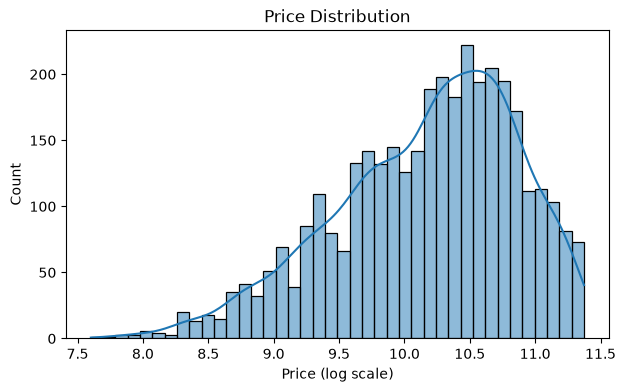

In [26]:
plt.figure(figsize=(7,4))
sns.histplot(np.log1p(df['price']), bins=40, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (log scale)')
plt.ylabel('Count')
plt.show()

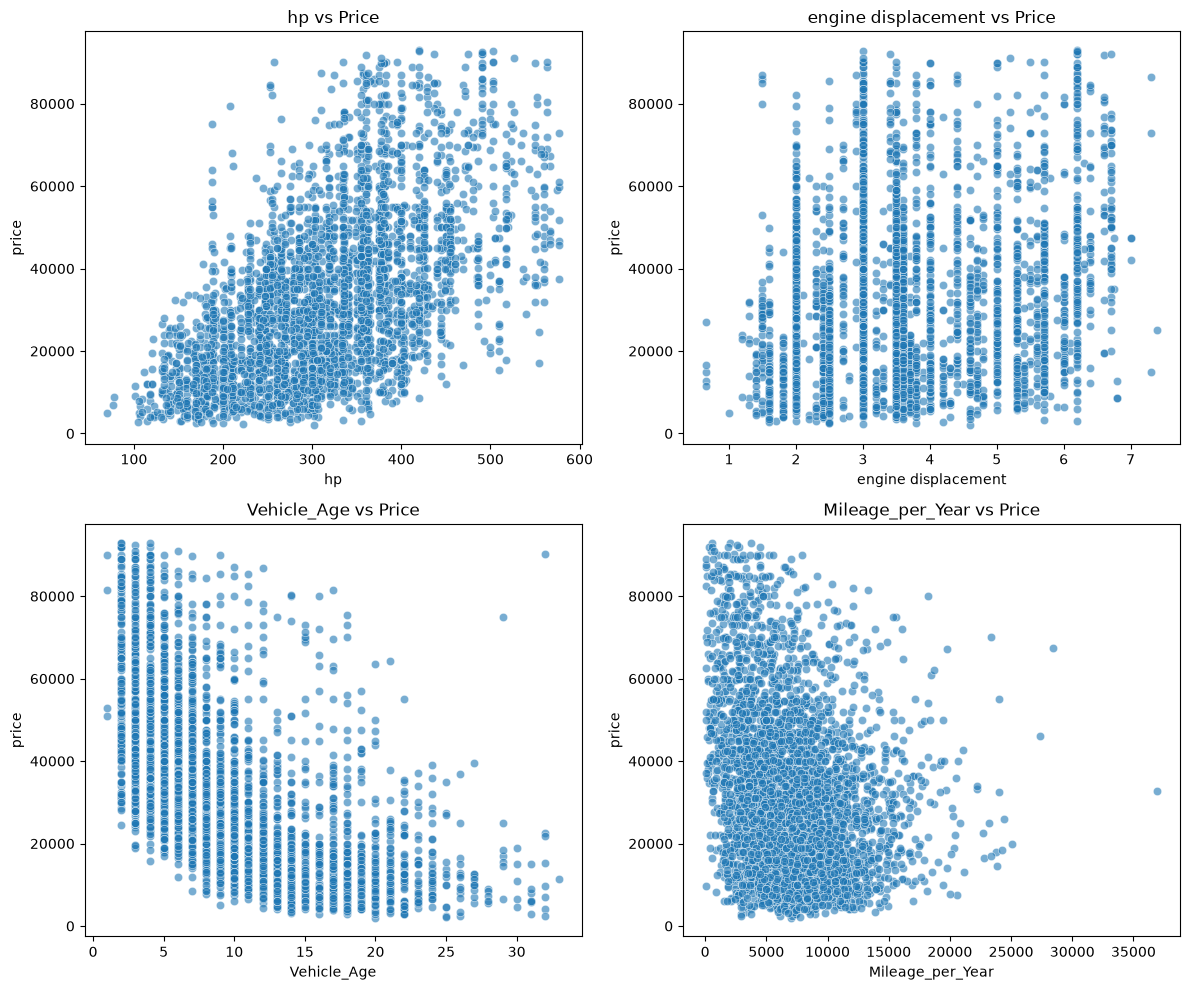

In [38]:
num_cols = ['hp','engine displacement','Vehicle_Age','Mileage_per_Year']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=df[col], y=df['price'], alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{col} vs Price')

plt.tight_layout()
plt.show()

<Axes: >

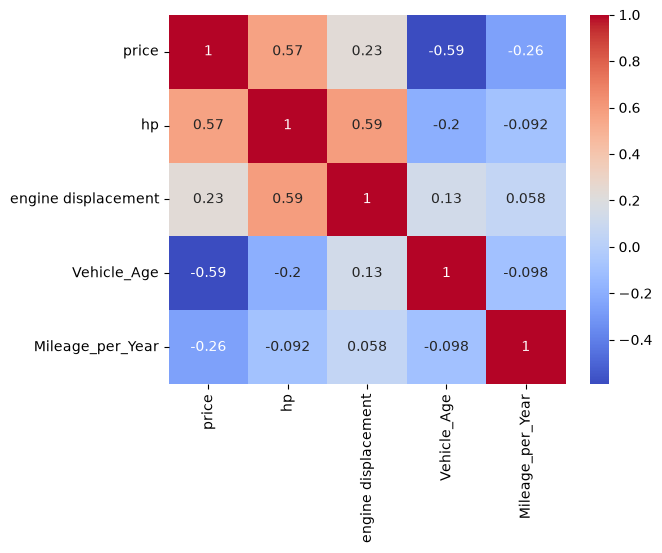

In [39]:
num_features = ['price','hp','engine displacement','Vehicle_Age','Mileage_per_Year']
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')

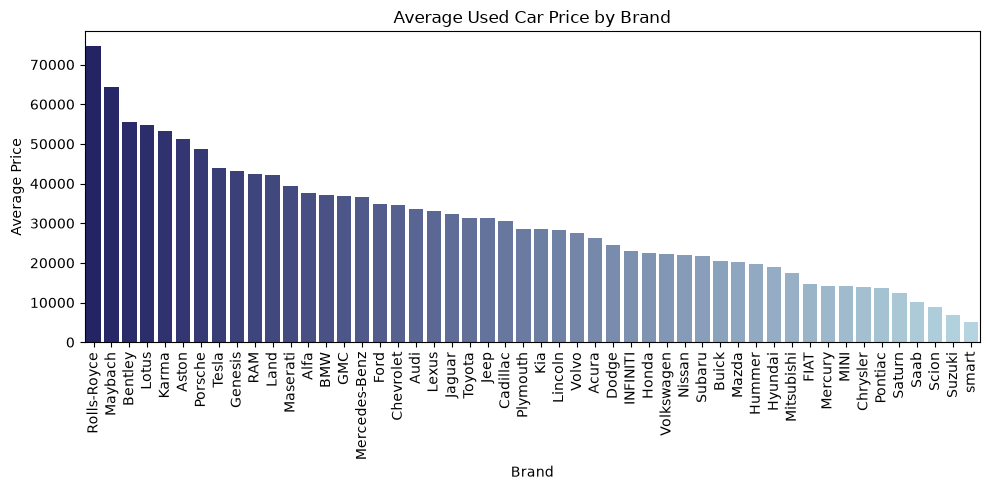

In [40]:
brand_avg_price = (
    vis_df.groupby('brand')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=brand_avg_price.index,
    y=brand_avg_price.values,
    palette=sns.color_palette("blend:midnightblue,lightblue", n_colors=len(brand_avg_price)
))
plt.xticks(rotation=90)
plt.title("Average Used Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

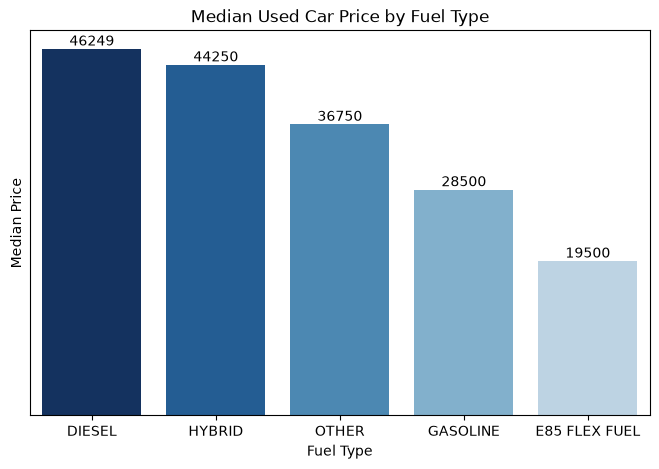

In [41]:
order = (
    vis_df.groupby('fuel_type')['price']
          .median()
          .sort_values(ascending=False)
          .index
)


medians = vis_df.groupby('fuel_type')['price'].median().loc[order]

# Color Grediant
cmap = plt.colormaps.get_cmap('Blues')
colors = [cmap(x) for x in np.linspace(1, 0.3, len(medians))]

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='fuel_type',
    y='price',
    data=vis_df,
    order=order,
    estimator=np.median,
    errorbar=None,
    palette=colors
)

plt.title("Median Used Car Price by Fuel Type")
plt.xlabel("Fuel Type")
ax.set_ylabel("Median Price")
ax.set_yticks([])   


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.show()

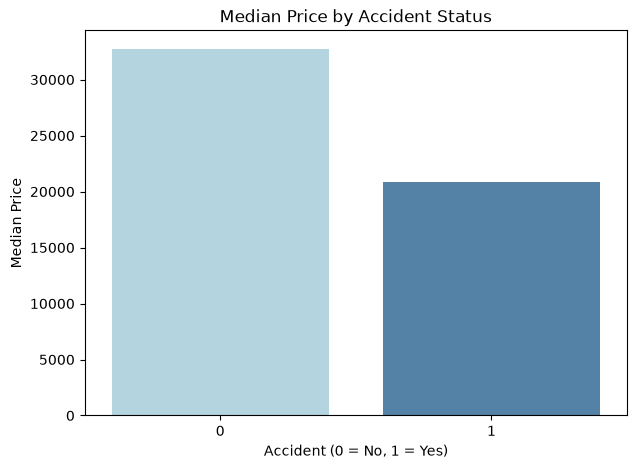

In [42]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Accident_Impact',
    y='price',
    data=vis_df,
    estimator=np.median,   
    errorbar=None,
    palette= ['lightblue','steelblue']
)

plt.title("Median Price by Accident Status")
plt.xlabel("Accident (0 = No, 1 = Yes)")
plt.ylabel("Median Price")
plt.show()

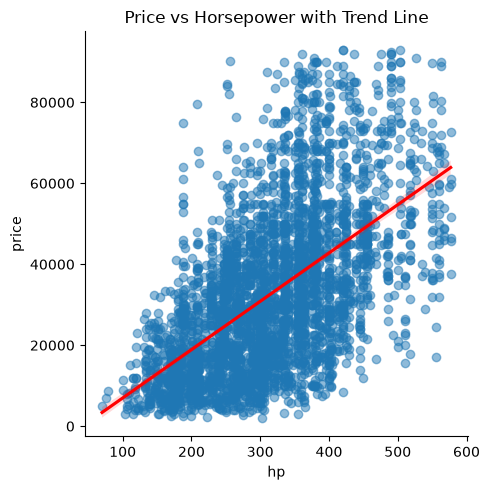

In [43]:
sns.lmplot(data=df, x='hp', y='price', line_kws={'color':'red'}, scatter_kws={'alpha':0.5})
plt.title('Price vs Horsepower with Trend Line')
plt.tight_layout()
plt.show()

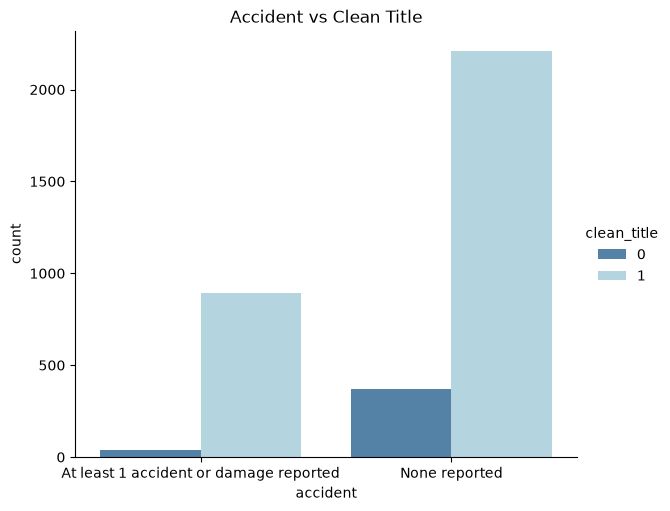

In [44]:
acc_ct = vis_df.groupby(['accident','clean_title']).size().reset_index(name='count')
sns.catplot(data=acc_ct, x='accident', y='count', hue='clean_title',
            kind='bar', height=5, aspect=1.2,
            palette = ["steelblue","lightblue"]
            )
plt.title('Accident vs Clean Title')
plt.show()

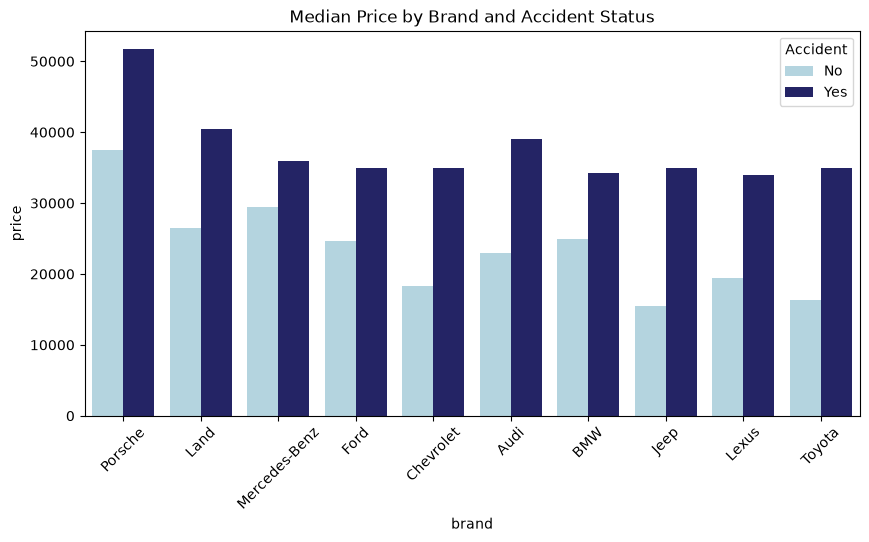

In [45]:
top_brands = vis_df['brand'].value_counts().nlargest(10).index

brand_order = (
    vis_df[vis_df['brand'].isin(top_brands)]
    .groupby('brand')['price']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=vis_df[vis_df['brand'].isin(top_brands)],
    x='brand',
    y='price',
    hue='accident',
    estimator=np.median,
    errorbar=None,
    order=brand_order,
    palette=['lightblue','midnightblue']   
)

plt.title('Median Price by Brand and Accident Status')
plt.xticks(rotation=45)

ax.legend(title="Accident", labels=["No", "Yes"])

plt.show()

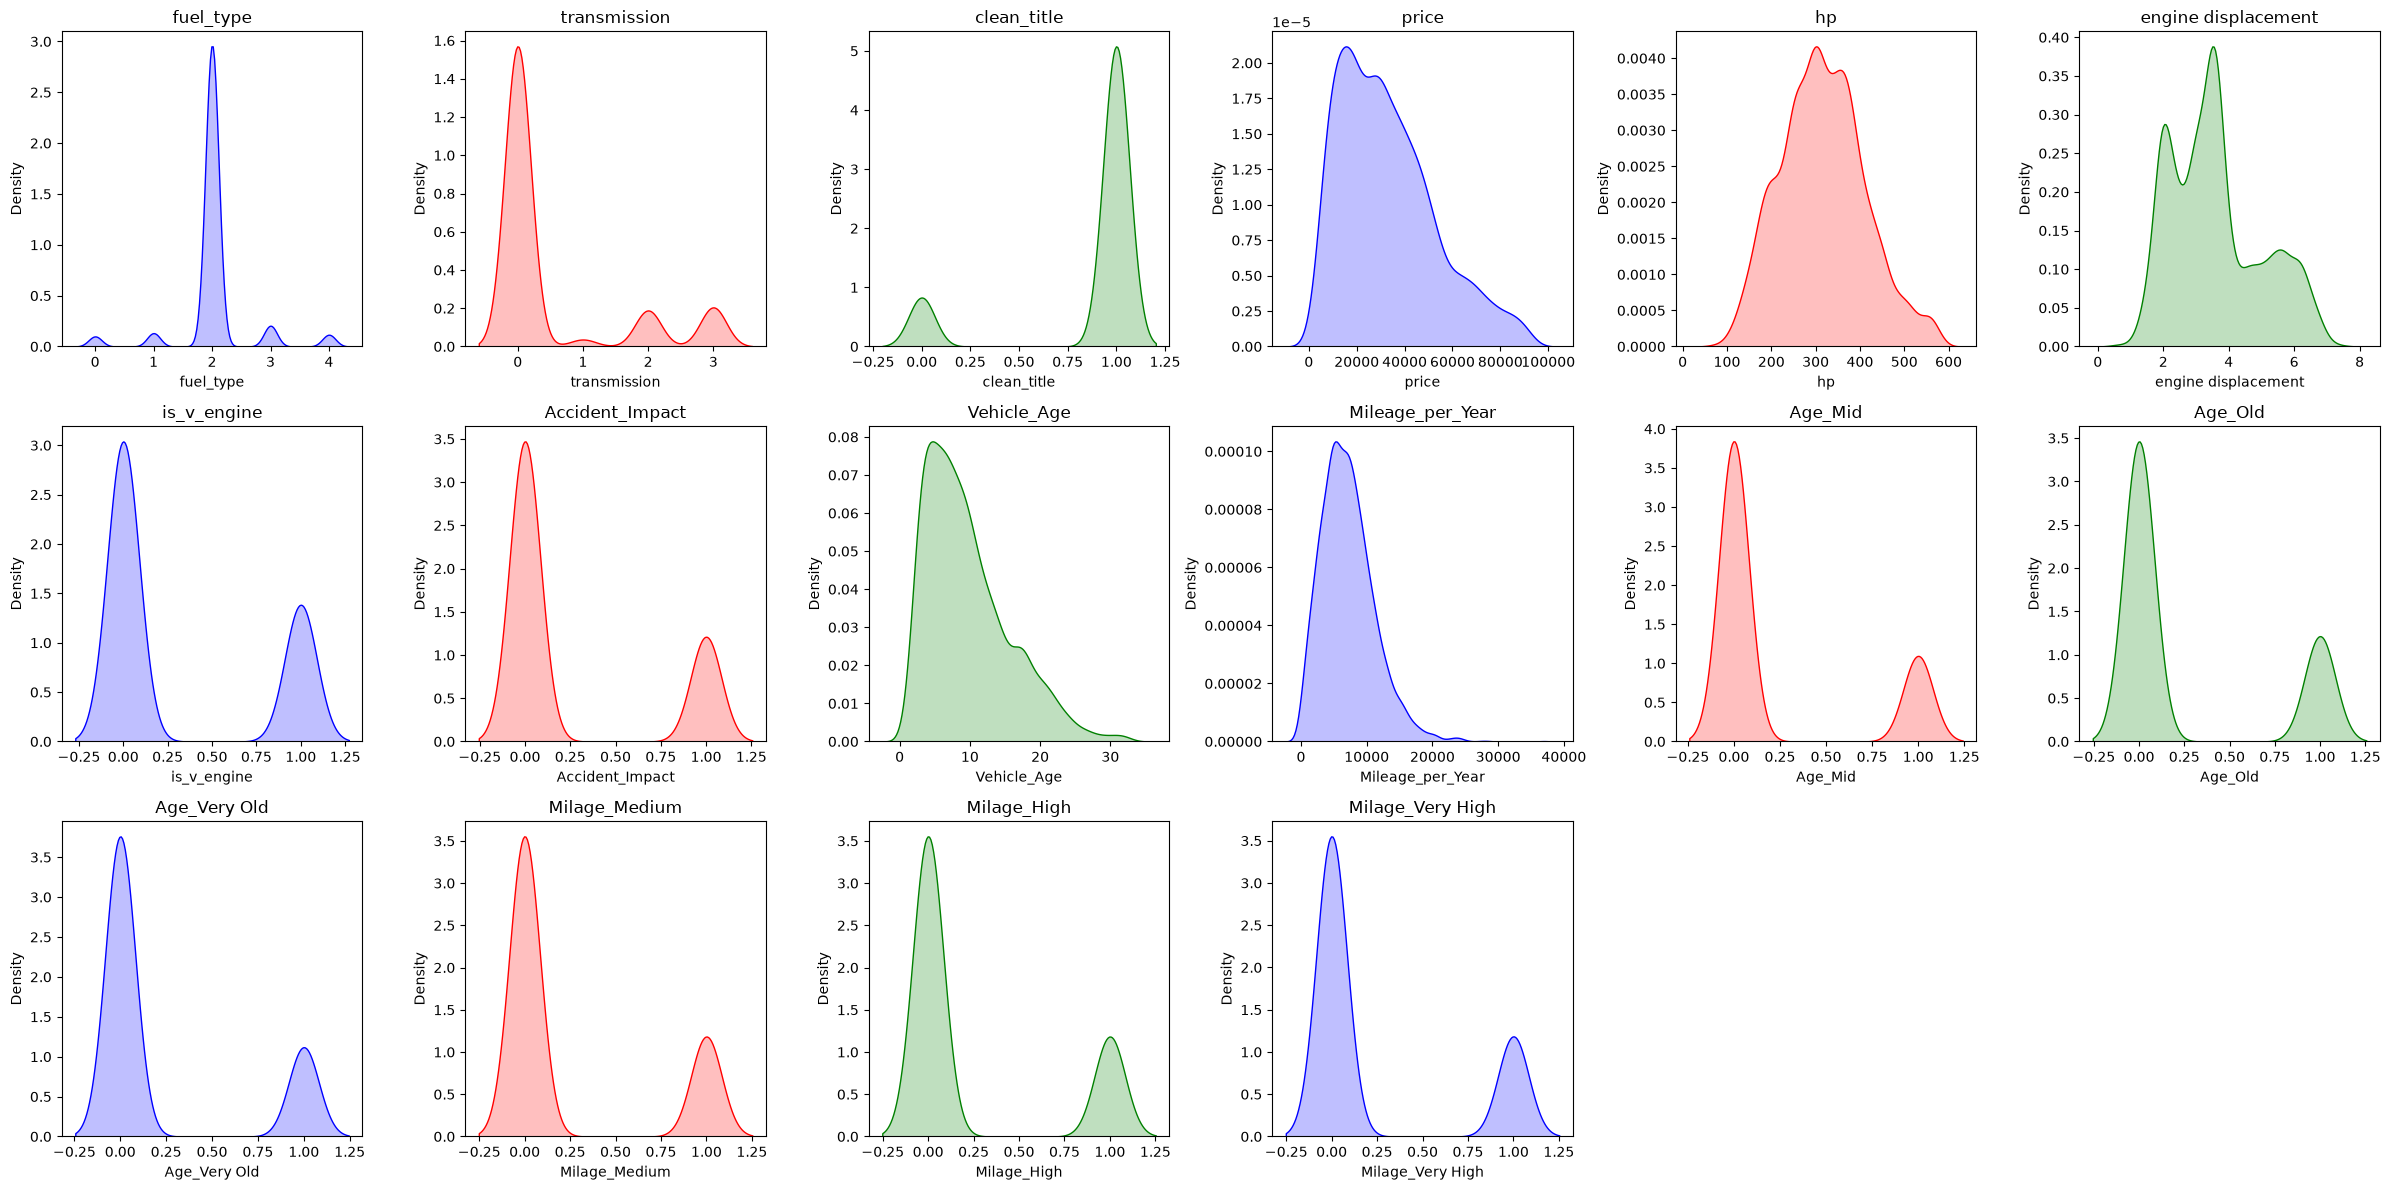

In [46]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

n_rows = 3
numeric_column_name = df.select_dtypes(include='number').columns
n_cols = int(np.ceil(len(numeric_column_name)/n_rows))
colors = ['blue', 'red', 'green']

plt.figure(figsize=(4*n_cols, 4*n_rows))
for idx, column in enumerate(numeric_column_name, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.kdeplot(
        data=df,
        x=column,
        fill=True,                      
        color=colors[(idx-1) % len(colors)]  
    )
    plt.title(column)
plt.tight_layout()
plt.show()

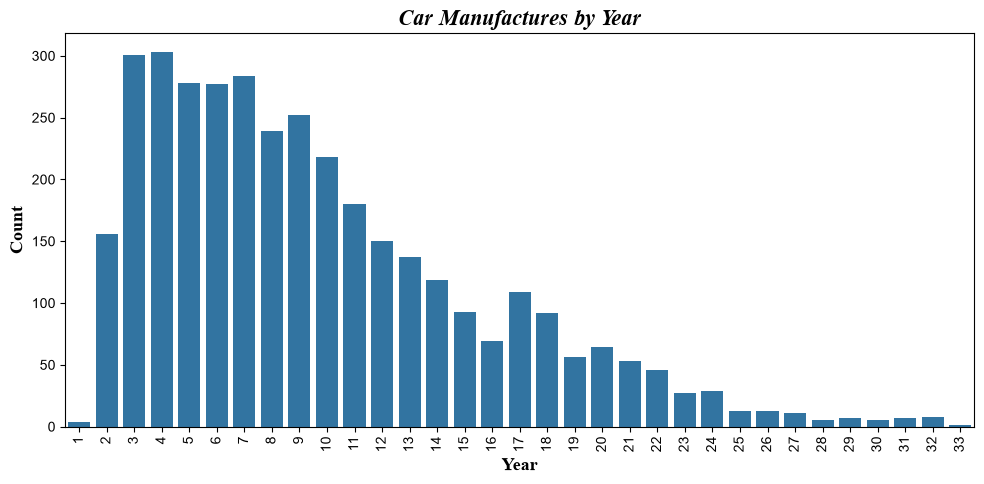

In [47]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Vehicle_Age', width=0.8)
plt.xticks(rotation=90)
plt.xlabel('Year', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.ylabel('Count', fontdict={'family': 'Times New Roman', 'size':13, 'weight': 'bold'})
plt.title('Car Manufactures by Year', fontdict={'family': 'Times New Roman', 'style': 'oblique', 'size':16, 'weight': 'bold'})
sns.set_style('darkgrid')
sns.set_theme('notebook')
plt.tight_layout()
plt.show()

# Section 6 — Train/Test Split

All models share **exactly the same** split, target and evaluation, which keeps the MLflow comparison fair.

* Features `X`: everything except `price` (the raw `brand` string is still included — it is encoded *inside* the model pipeline, fit on training data only).
* Target: `price` in dollars. The models are trained on `log1p(price)` as in the original notebook; this transform is wrapped **inside** the model (`TransformedTargetRegressor`), so predictions come out in dollars.
* Because `train_test_split` only uses row positions, `random_state=42` gives the same rows as the original notebook.

In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

X = df.drop(['price'], axis=1)
y = df['price']                       # target in dollars (log-transform happens inside the model)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
y_train_log = np.log1p(y_train)       # only used to tune hyper-parameters with GridSearchCV

assert (y > 0).all(), "MAPE needs strictly positive targets"

print(f"Rows after cleaning : {len(df)}  (raw: {n_rows_raw})")
print(f"Features            : {X.shape[1]}")
print(f"Train / Test rows   : {len(X_train)} / {len(X_test)}")

Rows after cleaning : 3554  (raw: 4009)
Features            : 16
Train / Test rows   : 2843 / 711


In [28]:
# Dataset / preprocessing facts that are logged to every MLflow run
FEATURE_COLUMNS = list(X.columns)

BASE_PARAMS = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_rows_raw": n_rows_raw,
    "n_rows_after_cleaning": len(df),
    "n_features": X.shape[1],
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "target": "price",
    "target_transform": "log1p (inverse: expm1)",
    "outlier_removal": "IQR 1.5x on engine displacement, hp, price, milage",
    "categorical_encoding": "LabelEncoder (fuel_type, transmission, is_v_engine) + one-hot age/mileage bins",
    "brand_encoding": "target mean of log-price, fit on train only",
    "feature_scaling": "StandardScaler",
    "feature_selection": "manual: dropped model, model_year, engine, milage, int_col, ext_col, accident",
}

DATASET_SUMMARY = {
    "feature_columns": FEATURE_COLUMNS,
    "price_describe": y.describe().round(2).to_dict(),
    "n_rows_raw": n_rows_raw,
    "n_rows_after_cleaning": len(df),
}

# Section 7 — Model Definitions

Every candidate is a **complete pipeline**, so preprocessing travels with the model:

```text
TransformedTargetRegressor( log1p / expm1 on price )
 └── Pipeline
      ├── BrandTargetEncoder   (brand -> brand_encoded)
      ├── StandardScaler
      └── model                (LinearRegression | Ridge | RandomForest | SVR | XGBoost)
```

Hyper-parameter grids for Random Forest, SVR and XGBoost are the ones from the original notebook (prefix `model__` because the estimator is a pipeline step).
Ridge is added as a cheap second linear baseline (it has an `alpha` to track). Two small deliberate changes versus the original, both needed to make the comparison fair and the model portable:

* `random_state=42` everywhere (the original used 40 for RF/XGBoost);
* XGBoost's early stopping on the *test set* is removed — it leaked test data into training and cannot work inside a pipeline.

In [29]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import xgboost

def build_pipeline(estimator):
    """Preprocessing + estimator (works on the raw feature frame X)."""
    return Pipeline([
        ("brand_encoder", BrandTargetEncoder(column="brand")),
        ("scaler", StandardScaler()),
        ("model", clone(estimator)),
    ])

def wrap_target_transform(pipeline):
    """Train on log1p(price), predict in dollars."""
    return TransformedTargetRegressor(regressor=clone(pipeline), func=np.log1p,
                                      inverse_func=np.expm1, check_inverse=False)

# ---- hyper-parameter grids -------------------------------------------------
if QUICK_RUN:
    CV_FOLDS = 3
    rf_grid  = {'model__n_estimators': [100], 'model__max_depth': [8, 12], 'model__min_samples_split': [5],
                'model__min_samples_leaf': [2], 'model__max_features': ['sqrt']}
    svr_grid = {'model__C': [1, 10], 'model__epsilon': [0.1], 'model__kernel': ['rbf'], 'model__gamma': ['scale']}
    xgb_grid = {'model__n_estimators': [100, 200], 'model__learning_rate': [0.03], 'model__max_depth': [5],
                'model__subsample': [0.9], 'model__colsample_bytree': [0.8], 'model__reg_lambda': [1], 'model__reg_alpha': [0]}
else:
    rf_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [8, 10, 12],
        'model__min_samples_split': [5, 10, 15],
        'model__min_samples_leaf': [2, 4, 6],
        'model__max_features': ['sqrt'],
    }
    svr_grid = {
        'model__C': [0.1, 1, 10, 100],
        'model__epsilon': [0.01, 0.1, 0.2, 0.5],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto'],
    }
    xgb_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.03],
        'model__max_depth': [5, 7],
        'model__subsample': [0.7, 0.9],
        'model__colsample_bytree': [0.6, 0.8],
        'model__reg_lambda': [1, 10],
        'model__reg_alpha': [0, 1],
    }
ridge_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}

# ---- candidates: one MLflow run each -----------------------------------------
# log_params = which hyper-parameters of the final estimator are logged to MLflow
CANDIDATES = {
    "LinearRegression": dict(estimator=LinearRegression(), param_grid=None,
                             log_params=["fit_intercept"]),
    "Ridge":            dict(estimator=Ridge(random_state=RANDOM_STATE), param_grid=ridge_grid,
                             log_params=["alpha", "fit_intercept"]),
    "RandomForest":     dict(estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), param_grid=rf_grid,
                             log_params=["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]),
    "SVR":              dict(estimator=SVR(), param_grid=svr_grid,
                             log_params=["C", "epsilon", "kernel", "gamma"]),
    "XGBoost":          dict(estimator=XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=1),
                             param_grid=xgb_grid,
                             log_params=["n_estimators", "learning_rate", "max_depth", "subsample",
                                         "colsample_bytree", "reg_lambda", "reg_alpha"]),
}

# Cross-validation scoring used while tuning (computed on the log-price scale, as in the original notebook)
CV_SCORING = {'R2': 'r2', 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error'}

print("Candidates:", list(CANDIDATES))

Candidates: ['LinearRegression', 'Ridge', 'RandomForest', 'SVR', 'XGBoost']


# Section 8 — MLflow Experiment Training: *Do we need to train at all?*

This is the **existing-model check**:

```text
artifacts/models/best_model.pkl exists  AND  FORCE_RETRAIN == False   ->  SKIP training (load the saved model in Section 14)
otherwise                                                              ->  train all candidates and create MLflow runs
```

The data loading and preprocessing above always run (they are cheap and needed for evaluation / inference); only the expensive
*training + MLflow logging* is skipped. To force a fresh experiment, set `FORCE_RETRAIN = True` in Section 1 or delete `artifacts/models/best_model.pkl`.

In [30]:
model_exists = MODEL_PATH.exists()
RUN_TRAINING = FORCE_RETRAIN or not model_exists

print("=" * 70)
if RUN_TRAINING:
    why = "FORCE_RETRAIN=True" if FORCE_RETRAIN else f"no saved model found at {MODEL_PATH}"
    print(f"TRAINING WILL RUN   ({why})")
else:
    print(f"EXISTING MODEL FOUND: {MODEL_PATH}")
    print("TRAINING IS SKIPPED -> the saved model will be loaded and evaluated (Section 14).")
    print("(set FORCE_RETRAIN = True to retrain)")
print("=" * 70)

TRAINING WILL RUN   (no saved model found at d:\MLOPS-2\artifacts\models\best_model.pkl)


# Section 9 — Model Evaluation (helpers)

Same evaluation for every model: predictions are in **dollars**, metrics are computed on the train and the test set.

| Metric | Meaning | Better |
|---|---|---|
| `mae`  | mean absolute error ($) | lower |
| `mse`  | mean squared error ($²) | lower |
| `rmse` | root mean squared error ($) — **primary metric** | lower |
| `r2`   | coefficient of determination | higher |
| `mape` | mean absolute percentage error (%) — valid because all prices are > 0 | lower |

Metric names are identical in every run (`train_*` / `test_*`), which is what lets MLflow plot and compare them.

In [31]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, root_mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

def regression_metrics(y_true, y_pred, prefix):
    mse = mean_squared_error(y_true, y_pred)
    return {
        f"{prefix}_mae":  mean_absolute_error(y_true, y_pred),
        f"{prefix}_mse":  mse,
        f"{prefix}_rmse": float(np.sqrt(mse)),
        f"{prefix}_r2":   r2_score(y_true, y_pred),
        f"{prefix}_mape": mean_absolute_percentage_error(y_true, y_pred) * 100,   # percent
    }

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    """Returns train_* and test_* metrics plus test predictions."""
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    return {**regression_metrics(y_tr, pred_tr, "train"), **regression_metrics(y_te, pred_te, "test")}, pred_te

def plot_actual_vs_predicted(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', label="perfect prediction")
    ax.set_xlabel("Actual Price"); ax.set_ylabel("Predicted Price")
    ax.set_title(f"Actual vs Predicted Price — {title}"); ax.legend()
    fig.tight_layout()
    return fig

def plot_residuals(y_true, y_pred, title):
    resid = np.asarray(y_true) - np.asarray(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(y_pred, resid, alpha=0.5); axes[0].axhline(0, color='r', ls='--')
    axes[0].set_xlabel("Predicted Price"); axes[0].set_ylabel("Residual (actual - predicted)")
    axes[0].set_title("Residuals vs Predicted")
    sns.histplot(resid, bins=40, kde=True, ax=axes[1]); axes[1].set_title("Residual distribution")
    fig.suptitle(f"Residuals — {title}"); fig.tight_layout()
    return fig

def get_importances(fitted_model):
    """Feature importance (tree models) or |coefficient| (linear models, features are standardised). None for e.g. RBF-SVR."""
    pipe = fitted_model.regressor_
    est = pipe.named_steps["model"]
    names = pipe.named_steps["brand_encoder"].columns_out_
    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=names), "importance"
    if hasattr(est, "coef_"):
        return pd.Series(np.abs(np.ravel(est.coef_)), index=names), "|standardised coefficient|"
    return None, None

def plot_importances(series, label, title):
    s = series.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=s.values, y=s.index, ax=ax)
    ax.set_xlabel(label); ax.set_title(f"Feature importance — {title}")
    fig.tight_layout()
    return fig

# Section 10 — MLflow Logging: one run per model

`train_and_log()` is the heart of the notebook. For one candidate it opens **one MLflow run** and records:

| What | How | Example |
|---|---|---|
| **Tags** (labels for searching) | `mlflow.set_tags` | `model_name`, `run_type`, library versions |
| **Parameters** (inputs / config) | `mlflow.log_params` | `random_state`, `n_features`, `n_estimators`, `alpha` … |
| **Metrics** (results) | `mlflow.log_metrics` | `test_rmse`, `test_mae`, `test_r2`, `train_rmse` … |
| **Artifacts** (files) | `log_figure`, `log_text`, `log_dict` | plots, CV table, config JSON |
| **Model** | `mlflow.sklearn.log_model` | full pipeline + signature + input example, under artifact path `model` |

In [32]:
SESSION_ID = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")   # groups all runs of one execution
CODE_PATHS = [str(SRC_DIR / "car_transformers.py")]                 # shipped inside the MLflow model so it can be re-loaded anywhere

def train_and_log(name, spec):
    pipeline = build_pipeline(spec["estimator"])
    t0 = time.time()

    with mlflow.start_run(run_name=name) as run:
        # ---- tags ----
        mlflow.set_tags({
            "run_type": "candidate",
            "model_name": name,
            "training_session": SESSION_ID,
            "sklearn_version": __import__("sklearn").__version__,
            "xgboost_version": xgboost.__version__,
            "python_version": platform.python_version(),
        })
        # ---- parameters: dataset + preprocessing + seed ----
        mlflow.log_params(BASE_PARAMS)
        mlflow.log_param("model_type", name)
        mlflow.log_param("estimator_class", type(spec["estimator"]).__name__)

        # ---- hyper-parameter tuning (same CV for every tuned model) ----
        search = None
        if spec["param_grid"]:
            search = GridSearchCV(pipeline, spec["param_grid"], scoring=CV_SCORING, refit="RMSE",
                                  cv=KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
            search.fit(X_train, y_train_log)
            best_pipeline = search.best_estimator_
            mlflow.log_params({
                "tuning_method": "GridSearchCV",
                "cv_folds": CV_FOLDS,
                "cv_refit_metric": "RMSE (log-price scale)",
                "grid_candidates": len(search.cv_results_["params"]),
            })
        else:
            best_pipeline = pipeline
            mlflow.log_param("tuning_method", "none")

        # ---- final model = target transform + (encoder -> scaler -> estimator) ----
        model = wrap_target_transform(best_pipeline)
        model.fit(X_train, y_train)
        fit_seconds = time.time() - t0

        # ---- parameters: the model's own hyper-parameters (tuned values for grid-searched models) ----
        est_params = model.regressor_.named_steps["model"].get_params()
        mlflow.log_params({k: est_params[k] for k in spec["log_params"]})

        # ---- metrics ----
        metrics, pred_te = evaluate_model(model, X_train, y_train, X_test, y_test)
        metrics["fit_seconds"] = fit_seconds
        if search is not None:   # cross-validation scores (log-price scale, positive values)
            i = search.best_index_
            metrics["cv_rmse_logscale"] = -search.cv_results_["mean_test_RMSE"][i]
            metrics["cv_mae_logscale"]  = -search.cv_results_["mean_test_MAE"][i]
            metrics["cv_r2_logscale"]   =  search.cv_results_["mean_test_R2"][i]
        mlflow.log_metrics(metrics)

        # ---- artifacts ----
        fig = plot_actual_vs_predicted(y_test, pred_te, name); mlflow.log_figure(fig, "plots/actual_vs_predicted.png"); plt.close(fig)
        fig = plot_residuals(y_test, pred_te, name);           mlflow.log_figure(fig, "plots/residuals.png");           plt.close(fig)
        imp, label = get_importances(model)
        if imp is not None:
            fig = plot_importances(imp, label, name); mlflow.log_figure(fig, "plots/feature_importance.png"); plt.close(fig)
        if search is not None:
            cv_df = pd.DataFrame(search.cv_results_)
            keep = [c for c in cv_df.columns if c.startswith("param_") or c.startswith("mean_test_") or c == "rank_test_RMSE"]
            mlflow.log_text(cv_df[keep].sort_values("rank_test_RMSE").to_csv(index=False), "cv/cv_results.csv")
        mlflow.log_dict({"model_name": name, "best_hyperparameters": {k: str(est_params[k]) for k in spec["log_params"]},
                         "base_params": BASE_PARAMS, "primary_metric": PRIMARY_METRIC}, "config/training_config.json")
        mlflow.log_dict(DATASET_SUMMARY, "config/dataset_summary.json")

        # ---- the model itself (complete pipeline, so preprocessing is included) ----
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(model, **{MODEL_ARG: "model"}, signature=signature,
                                 input_example=X_train.head(3), code_paths=CODE_PATHS,
                                 serialization_format="cloudpickle")   # custom transformer -> skops cannot be used

    print(f"  {name:<17} test RMSE = {metrics['test_rmse']:>9.2f} | test MAE = {metrics['test_mae']:>9.2f} | "
          f"test R2 = {metrics['test_r2']:.3f} | {fit_seconds:6.1f}s | run_id = {run.info.run_id}")
    return {"run_id": run.info.run_id, "model": model, "metrics": metrics}

### Run all experiments

Only executes when Section 8 decided that training is needed. Each model becomes its own run in the MLflow experiment.

In [33]:
results = {}

if RUN_TRAINING:
    print(f"Training {len(CANDIDATES)} candidates  (QUICK_RUN={QUICK_RUN}, session {SESSION_ID})\n")
    for model_name, spec in CANDIDATES.items():
        results[model_name] = train_and_log(model_name, spec)
    print("\nDone. All runs are stored in ./mlruns")
else:
    print("Skipped: an existing trained model was found (see Section 8). No new MLflow runs were created.") 

Training 5 candidates  (QUICK_RUN=False, session 20261006-061152)



  LinearRegression  test RMSE =  11019.53 | test MAE =   7762.73 | test R2 = 0.673 |    0.8s | run_id = 810f452479384ec1bb3cbb14a735c623


  Ridge             test RMSE =  11011.43 | test MAE =   7754.81 | test R2 = 0.673 |   13.1s | run_id = 72f1975ad85f41aba500c947414988af


  RandomForest      test RMSE =   8935.00 | test MAE =   6204.29 | test R2 = 0.785 |  489.4s | run_id = 646b1bd4cb9f404f914ec59aad812216


  SVR               test RMSE =   9121.42 | test MAE =   6328.28 | test R2 = 0.776 | 2678.5s | run_id = f2f0ffd054764f6787ca723b414af864


  XGBoost           test RMSE =   7461.33 | test MAE =   5151.48 | test R2 = 0.850 |  449.8s | run_id = 3bb6ac27d5e94be59e34bb0156fc996b

Done. All runs are stored in ./mlruns


                                                                        # Section 11 — Model Comparison

One row per model, evaluated on the same held-out test set. The table is saved to `artifacts/reports/comparison.csv`
(and logged to MLflow in Section 12). If training was skipped, the table from the last training run is shown instead.

In [34]:
COMPARISON_COLS = ["test_mae", "test_mse", "test_rmse", "test_r2", "test_mape", "train_rmse", "train_r2", "fit_seconds"]

if RUN_TRAINING:
    comparison = pd.DataFrame([
        {"model": n, "run_id": r["run_id"], **{c: r["metrics"][c] for c in COMPARISON_COLS}}
        for n, r in results.items()
    ])
    comparison = comparison.sort_values(PRIMARY_METRIC, ascending=True).reset_index(drop=True)   # lower RMSE = better
    comparison.to_csv(COMPARISON_PATH, index=False)
    print(f"Saved -> {COMPARISON_PATH}")
elif COMPARISON_PATH.exists():
    comparison = pd.read_csv(COMPARISON_PATH)
    print(f"Loaded previous comparison from {COMPARISON_PATH}")
else:
    comparison = None
    print("No comparison table available (no training has been run yet).")

if comparison is not None:
    display(comparison.drop(columns="run_id").style.format(
        {"test_mae": "{:,.0f}", "test_mse": "{:,.0f}", "test_rmse": "{:,.0f}", "test_r2": "{:.3f}",
         "test_mape": "{:.1f}%", "train_rmse": "{:,.0f}", "train_r2": "{:.3f}", "fit_seconds": "{:.1f}"}))

Saved -> d:\MLOPS-2\artifacts\reports\comparison.csv


,model,test_mae,test_mse,test_rmse,test_r2,test_mape,train_rmse,train_r2,fit_seconds
0,XGBoost,"5,151","55,671,484","7,461",0.850,18.4%,"4,370",0.948,449.8
1,RandomForest,"6,204","79,834,147","8,935",0.785,21.6%,"6,621",0.881,489.4
2,SVR,"6,328","83,200,304","9,121",0.776,22.2%,"7,459",0.848,2678.5
3,Ridge,"7,755","121,251,595","11,011",0.673,26.0%,"10,622",0.693,13.1
4,LinearRegression,"7,763","121,429,943","11,020",0.673,26.0%,"10,627",0.692,0.8


# Section 12 — Best Model Selection

**Selection rule: lowest `test_rmse`** (RMSE in dollars penalises large pricing mistakes most). MAE and R² are shown for reference.

> Learning note: picking the winner on the same test set that is reported is a simplification inherited from the original notebook.
> In a production setting you would select on cross-validation scores or a separate validation set.

What gets logged to MLflow here:

* every candidate run gets the param **`is_best_model`** (`True` / `False`) → filter in the UI with `params.is_best_model = 'True'`;
* a separate run **`model_comparison_summary`** stores `comparison.csv`, a comparison chart, and the winner's name / run id.

In [35]:
if comparison is not None:
    best_row  = comparison.sort_values(PRIMARY_METRIC, ascending=True).iloc[0]
    best_name = best_row["model"]
    best_run_id = best_row["run_id"]
    print(f"Best model : {best_name}")
    print(f"Selected by: lowest {PRIMARY_METRIC} = {best_row[PRIMARY_METRIC]:,.2f}")
    print(f"MLflow run : {best_run_id}")

Best model : XGBoost
Selected by: lowest test_rmse = 7,461.33
MLflow run : 3bb6ac27d5e94be59e34bb0156fc996b


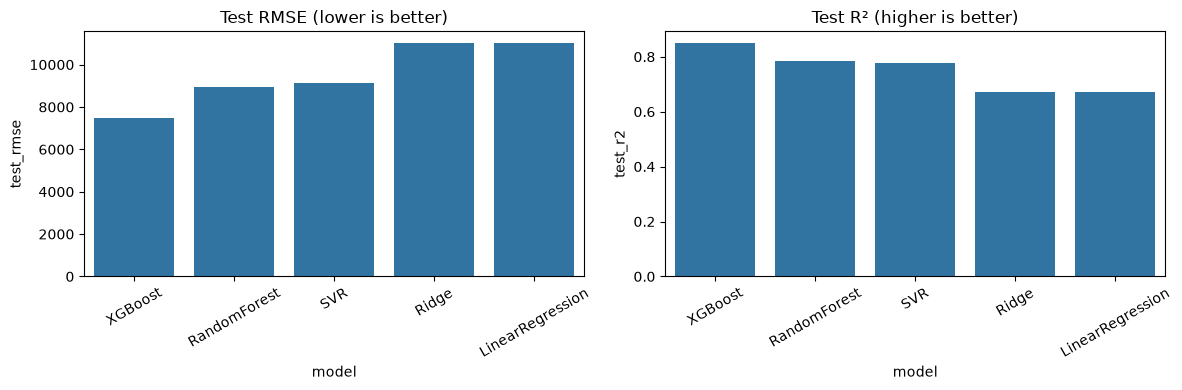

Summary run id: 79f3410606664266a6ba6683f5843ec6


In [36]:
SUMMARY_RUN_ID = None

if RUN_TRAINING:
    best_model = results[best_name]["model"]

    # 1) mark every candidate run
    client = MlflowClient()
    for n, r in results.items():
        client.log_param(r["run_id"], "is_best_model", n == best_name)

    # 2) summary run with the comparison table + chart
    with mlflow.start_run(run_name="model_comparison_summary") as summary:
        SUMMARY_RUN_ID = summary.info.run_id
        mlflow.set_tags({"run_type": "summary", "training_session": SESSION_ID})
        mlflow.log_params({"selection_metric": PRIMARY_METRIC, "selection_rule": "lowest value wins",
                           "best_model": best_name, "best_run_id": best_run_id, "n_candidates": len(results)})
        mlflow.log_metrics({f"best_{c}": float(best_row[c]) for c in ["test_mae", "test_mse", "test_rmse", "test_r2", "test_mape"]})
        mlflow.log_artifact(str(COMPARISON_PATH), artifact_path="comparison")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.barplot(data=comparison, x="model", y="test_rmse", ax=axes[0]); axes[0].set_title("Test RMSE (lower is better)")
        sns.barplot(data=comparison, x="model", y="test_r2",   ax=axes[1]); axes[1].set_title("Test R² (higher is better)")
        for a in axes: a.tick_params(axis="x", rotation=30)
        fig.tight_layout(); mlflow.log_figure(fig, "comparison/model_comparison.png")
        plt.show()
    print("Summary run id:", SUMMARY_RUN_ID)

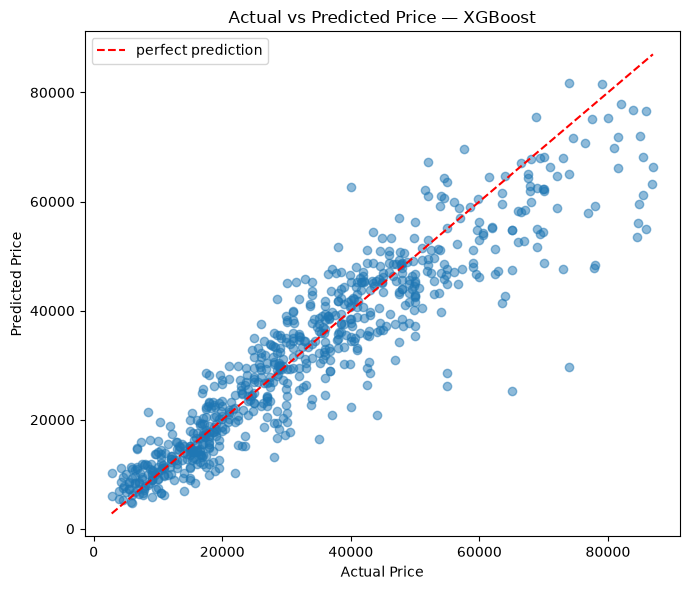

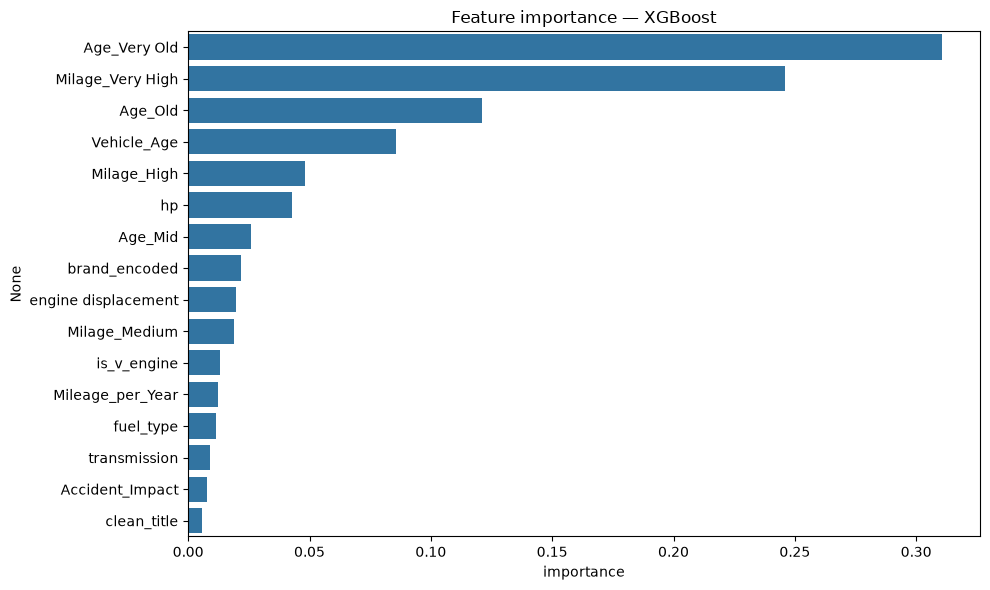

In [37]:
# Visual check of the winner (only available right after training; Section 14 shows the same for a loaded model)
if RUN_TRAINING:
    _, best_pred = evaluate_model(best_model, X_train, y_train, X_test, y_test)
    plot_actual_vs_predicted(y_test, best_pred, best_name); plt.show()
    imp, label = get_importances(best_model)
    if imp is not None:
        plot_importances(imp, label, best_name); plt.show()

# Section 13 — Save Best Model Locally

The saved object is the **complete model** (target transform → brand encoder → scaler → estimator), so later:

```python
model = joblib.load("artifacts/models/best_model.pkl")
model.predict(X_features)      # returns prices in dollars
```

`model_metadata.json` stores the model name, metrics, training time, MLflow run id, expected input columns and the label-encoder / bin definitions
that were used to build the features before the model.

In [38]:
if RUN_TRAINING:
    import sklearn

    joblib.dump(best_model, MODEL_PATH)

    metadata = {
        "model_name": best_name,
        "selection_metric": PRIMARY_METRIC,
        "selection_rule": "lowest value wins",
        "metrics": {k: float(v) for k, v in results[best_name]["metrics"].items()},
        "trained_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "mlflow": {"tracking_uri": TRACKING_URI, "experiment_name": EXPERIMENT_NAME,
                   "run_id": best_run_id, "summary_run_id": SUMMARY_RUN_ID, "model_artifact_path": "model"},
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "target": {"name": "price", "unit": "USD", "model_trains_on": "log1p(price)", "predict_returns": "price in USD"},
        "model_input": {
            "feature_columns": FEATURE_COLUMNS,                       # exact column names expected by model.predict()
            "dtypes": {c: str(t) for c, t in X_train.dtypes.items()},
            "note": "Input = the cleaned feature frame produced in Section 5 (raw 'brand' string included; "
                    "brand encoding + scaling + log-target happen inside the model).",
        },
        "feature_preparation": {                                       # needed to build the features from a raw listing at serving time
            "label_encoder_classes": label_encoder_classes,
            "vehicle_age_bin_edges": [float(v) for v in age_bin_edges],
            "mileage_bin_edges": [float(v) for v in mileage_bin_edges],
            "vehicle_age_reference_year": 2025,
        },
        "library_versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                             "xgboost": xgboost.__version__, "mlflow": mlflow.__version__,
                             "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
    }
    METADATA_PATH.write_text(json.dumps(metadata, indent=2))

    # keep a copy of the metadata next to the comparison table in MLflow
    with mlflow.start_run(run_id=SUMMARY_RUN_ID):
        mlflow.log_artifact(str(METADATA_PATH), artifact_path="model_metadata")

    print("Best model saved to  :", MODEL_PATH)
    print("Metadata saved to    :", METADATA_PATH)
else:
    print("Nothing to save: training was skipped, the existing model stays untouched ->", MODEL_PATH)

Best model saved to  : d:\MLOPS-2\artifacts\models\best_model.pkl
Metadata saved to    : d:\MLOPS-2\artifacts\models\model_metadata.json


# Section 14 — Load Existing Model / Inference

This cell runs on **every execution** — on the first run it reloads the model that was just written (proving the file works),
on later runs it simply loads the existing model **without retraining**, then evaluates it on the same test split.

In [39]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"{MODEL_PATH} does not exist - run the notebook with training enabled first.")

loaded_model = joblib.load(MODEL_PATH)
saved_meta = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}

print("Loaded model        :", saved_meta.get("model_name", "?"))
print("Trained at (UTC)    :", saved_meta.get("trained_at_utc", "?"))
print("MLflow run id       :", saved_meta.get("mlflow", {}).get("run_id", "?"))

# Evaluate on the held-out test split
test_pred = loaded_model.predict(X_test)
loaded_metrics = regression_metrics(y_test, test_pred, "test")
print("\nTest metrics of the loaded model:")
for k, v in loaded_metrics.items():
    print(f"  {k:<10}{v:>14,.3f}")

if "metrics" in saved_meta and np.isclose(saved_meta["metrics"].get("test_rmse", np.nan), loaded_metrics["test_rmse"], rtol=1e-6):
    print("\n✔ Matches the test RMSE stored when the model was trained (same data split, same model).")

Loaded model        : XGBoost
Trained at (UTC)    : 2026-10-06T07:18:58+00:00
MLflow run id       : 3bb6ac27d5e94be59e34bb0156fc996b

Test metrics of the loaded model:
  test_mae       5,151.476
  test_mse  55,671,484.000
  test_rmse      7,461.333
  test_r2            0.850
  test_mape         18.431

✔ Matches the test RMSE stored when the model was trained (same data split, same model).


In [40]:
# Example inference: predict prices for a few cars
sample = X_test.head(10)
preds = loaded_model.predict(sample)

pd.DataFrame({
    "brand": sample["brand"].values,
    "actual_price": y_test.loc[sample.index].values,
    "predicted_price": preds.round(0),
    "abs_error": np.abs(y_test.loc[sample.index].values - preds).round(0),
})

,brand,actual_price,predicted_price,abs_error
0,Subaru,19500,15150.0,4350.0
1,Jeep,41599,45194.0,3595.0
2,Ford,20000,20706.0,706.0
3,Volkswagen,9750,7224.0,2526.0
4,Ford,13715,15607.0,1892.0
5,Ford,67500,65085.0,2415.0
6,Land,60500,53916.0,6584.0
7,Chevrolet,7000,8448.0,1448.0
8,Audi,19500,20160.0,660.0
9,BMW,65000,47405.0,17595.0


In [41]:
# One single car -> one price (this is what a future API endpoint would do)
one_car = X_test.iloc[[0]]
print("Predicted price: $", round(float(loaded_model.predict(one_car)[0])))

Predicted price: $ 15150


# Section 15 — Explore the Results in the MLflow UI

Open a terminal **in the project folder** (the one that contains `mlruns/`) and run:

```bash
# macOS / Linux
MLFLOW_ALLOW_FILE_STORE=true mlflow ui --backend-store-uri ./mlruns

# Windows PowerShell
$env:MLFLOW_ALLOW_FILE_STORE="true"; mlflow ui --backend-store-uri ./mlruns
```

(`MLFLOW_ALLOW_FILE_STORE` is only needed with MLflow 3.x, which marks the plain-folder store as legacy; on older versions the short form `mlflow ui --backend-store-uri ./mlruns` works.
The modern alternative is a SQLite store: set `TRACKING_URI = "sqlite:///mlflow.db"` in Section 2 and run `mlflow ui --backend-store-uri sqlite:///mlflow.db`.)

Then open <http://127.0.0.1:5000> and click the experiment **`used-car-price-prediction`**. (The server is *not* started from the notebook.)

**What to try**

* **Runs** — one row per model (`LinearRegression`, `Ridge`, `RandomForest`, `SVR`, `XGBoost`) plus `model_comparison_summary`.
* **Compare** — tick several runs and click *Compare*: parameters side by side, metric bar/parallel-coordinate charts.
* **Parameters** — `n_estimators`, `max_depth`, `alpha`, `C`, `random_state`, `n_features`, … Filter e.g. `params.model_type = "RandomForest"`.
* **Metrics** — sort the table by `metrics.test_rmse`; the *Chart view* plots `test_*` vs `train_*` metrics (overfitting is easy to spot).
* **Artifacts** — open a run → *Artifacts*: `plots/` (actual vs predicted, residuals, feature importance), `cv/cv_results.csv`, `config/`, and the `model/` folder (`MLmodel`, signature, input example, `requirements.txt`).
* **Best model** — filter with `params.is_best_model = "True"`; the `model_comparison_summary` run holds `comparison.csv`.

In [42]:
# The same information is available from Python:
try:
    runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME], order_by=["metrics.test_rmse ASC"])
    cols = [c for c in ["tags.mlflow.runName", "params.is_best_model", "metrics.test_rmse", "metrics.test_mae",
                        "metrics.test_r2", "metrics.test_mape", "run_id"] if c in runs.columns]
    display(runs[cols].head(15))
except Exception as e:
    print("No runs to show yet:", e)

,tags.mlflow.runName,params.is_best_model,metrics.test_rmse,metrics.test_mae,metrics.test_r2,metrics.test_mape,run_id
0,XGBoost,True,7461.332589,5151.475586,0.850055,18.430600,3bb6ac27d5e94be59e34bb0156fc996b
1,RandomForest,False,8934.995634,6204.291138,0.784976,21.588699,646b1bd4cb9f404f914ec59aad812216
2,SVR,False,9121.420060,6328.277824,0.775910,22.213431,f2f0ffd054764f6787ca723b414af864
3,RandomForest,None,9532.713309,6328.007225,0.770078,22.584882,bc4d7ef42c0d4953b509fd5c85c4f9d6
4,Ridge,False,11011.430185,7754.805874,0.673423,26.017599,72f1975ad85f41aba500c947414988af
5,LinearRegression,False,11019.525549,7762.729583,0.672943,26.023916,810f452479384ec1bb3cbb14a735c623
6,Ridge,None,11656.581100,7911.675603,0.656213,27.438527,c2f1a5b77e66488ea255862de5f65c9b
7,LinearRegression,None,11664.237573,7916.082594,0.655761,27.430102,528f92036a2446309c185fa0c89592b7
8,model_comparison_summary,None,NaN,NaN,NaN,NaN,79f3410606664266a6ba6683f5843ec6
9,SVR,None,NaN,NaN,NaN,NaN,0e46ccb68dff457a89cf85540c83830d


---
# Reference: Original Kaggle Summary

*Results of the original notebook (random_state 40 for RF/XGBoost, XGBoost early-stopped on the test set). Numbers produced by the MLflow version above will differ slightly — check the comparison table in Section 11.*

| Model                    | Test RMSE | Test R²  |
|--------------------------|-----------|----------|
| Linear Regression        | ~10770.80 | 0.66     |
| Random Forest            | ~9446.60  | 0.77     |
| Support Vector Regressor | ~9756.67  | 0.76     |
| XGBoost                  | ~8176.96  | 0.83     |